# Домашнее задание "Оценка качества генерации текста с помощью метрик"

## Часть 1. Подготовка

### **Выбор трека и обоснование**



Для эксперимента выбран трек B: суммаризация новостных статей.

Суммаризация - широко востребованная задача во многих бизнес-процессах у меня на работе. Хочется оценить, насколько хорошо справятся модели, заточенные под суммаризацию по сравнению с обычными ллм, а также сравнить между собой модели на разной архитектуре.

Также важно продемонстрировать, как разные метрики улавливают сохранение фактов и структуры исходного текста.

### **Датасет для суммаризации**

Используется открытый датасет [Gazeta от IlyaGusev](https://huggingface.co/datasets/IlyaGusev/gazeta).

Он содержит ~74k новостных статей на русском языке с краткими эталонными саммари, составленными журналистами:

> Texts and summaries were written by journalists at Gazeta.



Каждая запись включает:

text: полный текст новости

summary: короткое резюме новости

title: заголовок статьи;

date: дата публикации;

url: ссылка на статью.

Референсные саммари из датасета будем использовать как эталон для расчёта метрик качества.

### **Выбор моделей для сравнения**

**Модель A:**

RuT5-base SumGazeta [IlyaGusev/rut5_base_sum_gazeta](https://huggingface.co/IlyaGusev/rut5_base_sum_gazeta) – энкодер-декодер модель типа T5, специально дообученная на русском датасете Gazeta для суммаризации. Ожидаем, что специализация на задаче и русском языке даст высокое качество. В предыдущих оценках на Gazeta эта модель показала ROUGE-1 F≈32%.
Базируется на https://huggingface.co/cointegrated/rut5-base

**Модель B:**

RuGPT3-medium SumGazeta [IlyaGusev/rugpt3medium_sum_gazeta](https://huggingface.co/IlyaGusev/rugpt3medium_sum_gazeta) – декодерная GPT-модель (345 млн параметров) на русском, тоже обученная на том же датасете. Интересно сравнить архитектуру GPT с T5. По отчётам, качество этой модели ниже (ROUGE-1 F≈26% на Gazeta).

Базируется на https://huggingface.co/ai-forever/rugpt3medium_based_on_gpt2



*Таким образом, обе модели обучены на одних данных, но отличаются архитектурой (Encoder-Decoder vs Causal LM). Эксперимент поможет оценить, как архитектура влияет на метрики и ошибки.*

**Модель C:**

[Qwen2.5-3B-Instruct](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct) (Prompt Summarization) — Qwen/Qwen2.5-3B-Instruct
Instruction-модель (CausalLM) ≈3B параметров, не дообучена на Gazeta, поэтому суммаризацию делаем через промпт (zero-shot / few-shot).
Это даст сравнение - спец. суммаризаторы vs универсальная instruct-модель.

*Выбираем небольшие локальные модели, которые можно запустить на GPU T4 в Colab. Чтобы избежать нехватки памяти, загружаем модели по очереди и очищаем GPU при переключении (gc.collect() и torch.cuda.empty_cache() между загрузками).*

*A и B обучены на одном датасете, но архитектуры разные (Encoder–Decoder vs Causal LM) → сравниваем влияние архитектуры.

C — универсальная instruct-модель → проверяем, насколько она может конкурировать с fine-tuned суммаризаторами.*

**Модель D**

Оценщик (LLM-as-a-Judge): GPT-4 в облаке OpenAI

## Установка зависимостей

In [1]:
!pip -q install -U transformers datasets evaluate rouge-score sacrebleu sentence-transformers accelerate bitsandbytes

In [2]:
!pip -q install -U openai

In [3]:
import random
import gc, time, re
import numpy as np
import pandas as pd
import torch
import evaluate

from rouge_score import rouge_scorer
import sacrebleu

from sentence_transformers import SentenceTransformer, util

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [4]:
def free_gpu(*objs):
    for o in objs:
        try:
            del o
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def char_len(s: str) -> int:
    return len(s) if isinstance(s, str) else 0

def now():
    return time.time()

## Загрузка датасета

In [5]:
from datasets import load_dataset

ds = load_dataset("IlyaGusev/gazeta")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 60964
    })
    validation: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6369
    })
    test: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6793
    })
})

In [6]:
print(ds["test"][0].keys())
print("\nTITLE:", ds["test"][0]["title"])
print("\nTEXT (source):", ds["test"][0]["text"][:1000])
print("\nSUMMARY (gold):", ds["test"][0]["summary"][:1000])

dict_keys(['text', 'summary', 'title', 'date', 'url'])

TITLE: В Германии объяснили упоминание имени Путина на протестах в Берлине 

TEXT (source): На этих выходных в Берлине прошли крупные акции протеста против введенных для борьбы с коронавирусом ограничений. Демонстранты скандировали «Путин!» По словам депутата городской палаты представителей Гуннара Линдеманна («Альтернатива для Германии»), люди выкрикивали фамилию российского президента из уважения к нему. В комментарии РИА «Новости» немецкий политик отметил, что среди населения Германии Владимир Путин имеет хорошую репутацию. По его мнению, протестующие ранее пришли к российскому посольству, чтобы «привлечь внимание к условиям в Германии», надеясь, что Россия сможет оказать влияние на канцлера ФРГ Ангелу Меркель. «На мой взгляд, опасности для посольства России не возникло ни разу», — сказал депутат. Несмотря на то что протест оказался массовым, выступления носили «преимущественно мирный характер», уверен Линдеманн. По его словам,

In [7]:
N_SAMPLES = 30

eval_ds = ds["test"].shuffle(seed=SEED).select(range(N_SAMPLES))

df_eval = pd.DataFrame({
    "title": [x["title"] for x in eval_ds],
    "text": [x["text"] for x in eval_ds],
    "reference_summary": [x["summary"] for x in eval_ds],
})

df_eval.head(5)

,title,text,reference_summary
0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...
1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...
2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...
3,Спецпредставитель президента ожидает новой «бы...,Спецпредставитель президента РФ по связям с ме...,Анатолий Чубайс заявил о формировании в ближай...
4,Жириновский упрекнул Азербайджан после протест...,МИД Азербайджана вызвал временного поверенного...,"Лидер ЛДПР, депутат Владимир Жириновский вызва..."


In [8]:
df_eval["text_len_chars"] = df_eval["text"].str.len()
df_eval["ref_len_chars"] = df_eval["reference_summary"].str.len()

df_eval[["text_len_chars", "ref_len_chars"]].describe()

,text_len_chars,ref_len_chars
count,30.000000,30.000000
mean,4460.566667,326.066667
std,1231.370828,52.914983
min,2924.000000,205.000000
25%,3689.000000,302.750000
50%,4245.500000,327.000000
75%,5018.750000,365.000000
max,8758.000000,398.000000


text_len_chars — длина исходной статьи (новость) в символах

ref_len_chars — длина эталонного summary в символах

**📰 Длина исходных текстов (text_len_chars)**
- Средняя длина: 4460 символов

- Медиана: 4245 символов

➡️ Это значит: типичная новость в датасете — примерно 4–4.5 тыс. символов.

➡️ В выборке есть как умеренные тексты, так и очень длинные статьи.

**Квантили:**

- 25% текстов короче 3689

- 50% (медиана) около 4245

- 75% короче 5019

➡️ То есть половина датасета лежит примерно в диапазоне 3.7k – 5.0k символов, а длинные тексты — это скорее исключения.

**🧾 Длина эталонных саммари (ref_len_chars)**

- Средняя длина: 326 символов

- Медиана: 327 символов

➡️ Эталонное резюме почти всегда короткое, около 320–330 символов.

# Часть 2. Реализация метрик

**Обязательные метрики для всех треков:**
- Semantic Similarity.
- Время генерации ответа.
- Длина сгенерированного текста.


**Специализированные метрики по трекам:**

Трек B (Summarization): ROUGE-1, ROUGE-L, BLEU

Доп. метрика - LLM-as-a-Judge

**Интерпретация метрик:**

**ROUGE-1:** Совпадение униграмм (отдельных слов). Отражает информативность.

**ROUGE-L:** Учитывает самую длинную общую подпоследовательность. Отражает сохранение структуры предложения.

**Ограничения:** Автоматические метрики чувствительны к полному совпадению слов. Высокий балл ROUGE может быть получен путем копирования фрагментов исходного текста (extractive bias), даже если смысл передан не полностью.

**BLEU:** метрика заимствована из машинного перевода, измеряет точность n-граммов модели относительно эталона с учетом штрафа за длину. BLEU считаем в основном для дополнительной перспективы: он фокусируется на точности формулировок (precision), а не полноте.

Автоматические метрики вроде ROUGE и BLEU – лишь приближение к оценке качества. Они чувствительны к точному совпадению слов и не умеют понимать смысл. Например, высокий ROUGE-score модель может получить, просто выдав несколько предложений из исходника, даже если пропущены важные нюансы смысла.

Поэтому мы включаем семантическую метрику и LLM-оценку, чтобы получить более полное представление. Комбинация разных метрик позволяет оценить генерацию со всех сторон: покрытие фактов, точность формулировок, сохраняемость структуры и смысловую близость.

**Semantic Similarity (семантическое сходство)**

Метрика отражает, насколько смысл сгенерированного саммари близок к смыслу референсного. В отличие от подсчёта точных совпадений слов, семантическая метрика учитывает перефразирование. Реализация с помощью эмбеддингов: вычисляем sentence embedding для сгенерированного и референсного резюме и считаем косинусное сходство. Высокое значение (близкое к 1.0) означает, что модель передала основные факты верно, даже если слова отличаются.

**Оценщик (LLM-as-a-Judge)**
дополнительный качественный метод – использование крупной языковой модели для оценки качества суммари.
LLM может учитывать факты, перефразирование, отсутствие искажения смысла – то, что не всегда улавливают простые метрики.

In [9]:
# Семантическая близость
sim_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
sim_model = SentenceTransformer(sim_model_name, device="cpu")
print("✅ Semantic model:", sim_model_name)

✅ Semantic model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [10]:
import evaluate
import sacrebleu
import numpy as np

# Загружаем ROUGE через evaluate
rouge = evaluate.load("rouge")

def bleu_score(pred: str, ref: str):
    return sacrebleu.sentence_bleu(pred, [ref]).score

def compute_rouge_per_sample(preds, refs):
    """
    Возвращает rouge1 и rougeL per-sample
    use_stemmer=False важно для русского языка.
    """
    scores = rouge.compute(
        predictions=preds,
        references=refs,
        use_aggregator=False,
        use_stemmer=False
    )
    # scores["rouge1"] и scores["rougeL"] будут списками длины N
    return scores["rouge1"], scores["rougeL"]

def semantic_sim(preds, refs):
    emb_pred = sim_model.encode(preds, convert_to_tensor=True, normalize_embeddings=True)
    emb_ref  = sim_model.encode(refs,  convert_to_tensor=True, normalize_embeddings=True)
    sims = util.cos_sim(emb_pred, emb_ref).diagonal().cpu().numpy()
    return sims

def compute_all_metrics(df_pred: pd.DataFrame):
    """
    df_pred должен иметь колонки: pred, reference_summary, gen_time_sec, pred_len_chars
    Добавляем per-sample метрики + считаем агрегаты по run.
    """
    preds = df_pred["pred"].tolist()
    refs  = df_pred["reference_summary"].tolist()

    # ✅ ROUGE per-sample
    r1_list, rL_list = compute_rouge_per_sample(preds, refs)
    df_pred["rouge1"] = r1_list
    df_pred["rougeL"] = rL_list

    # ✅ BLEU per-sample
    df_pred["bleu"] = [bleu_score(p, r) for p, r in zip(preds, refs)]

    # ✅ Semantic similarity per-sample
    df_pred["sem_sim"] = semantic_sim(preds, refs)

    # ✅ Агрегаты (mean)
    agg = {
        "rouge1_mean": float(np.mean(df_pred["rouge1"])),
        "rougeL_mean": float(np.mean(df_pred["rougeL"])),
        "bleu_mean": float(np.mean(df_pred["bleu"])),
        "sem_sim_mean": float(np.mean(df_pred["sem_sim"])),
        "gen_time_mean": float(np.mean(df_pred["gen_time_sec"])),
        "pred_len_chars_mean": float(np.mean(df_pred["pred_len_chars"])),
    }

    return df_pred, agg

# Часть 3. Эксперименты:

## Инициализация моделей и вспомогательных функций

In [11]:
from transformers import AutoTokenizer, T5ForConditionalGeneration

MODEL_A = "IlyaGusev/rut5_base_sum_gazeta"

def load_rut5():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_A)
    model = T5ForConditionalGeneration.from_pretrained(
        MODEL_A,
        torch_dtype=torch.float16 if torch.cuda.is_available() else None,
        device_map="auto"
    )
    model.eval()
    return tokenizer, model

@torch.inference_mode()
def gen_rut5(tokenizer, model, text: str, max_source_len=600, max_new_tokens=200):
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=max_source_len,
        padding="max_length",
        return_tensors="pt"
    ).to(model.device)

    t0 = now()
    out = model.generate(
        **inputs,
        num_beams=5,
        no_repeat_ngram_size=4,
        early_stopping=True,
        max_new_tokens=max_new_tokens
    )
    t = now() - t0
    pred = tokenizer.decode(out[0], skip_special_tokens=True)
    return pred, t


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_B = "IlyaGusev/rugpt3medium_sum_gazeta"

def load_rugpt3():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_B)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_B,
        torch_dtype=torch.float16 if torch.cuda.is_available() else None,
        device_map="auto"
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    return tokenizer, model

def build_rugpt_prompt(text: str):
    # минимальный промпт (модель fine-tuned, но лучше явно указать задачу)
    return f"Сделай краткое содержание новости:\n{text}\n\nКратко:"

@torch.inference_mode()
def gen_rugpt3(tokenizer, model, text: str, max_input_len=1024, max_new_tokens=150, temperature=0.7):
    prompt = build_rugpt_prompt(text)

    enc = tokenizer(
        prompt,
        truncation=True,
        max_length=max_input_len,
        return_tensors="pt"
    ).to(model.device)

    input_len = enc["input_ids"].shape[1]

    t0 = now()
    out = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id
    )
    t = now() - t0

    gen_tokens = out[0][input_len:]  # только "новая" часть
    pred = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
    return pred, t


In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch, time

MODEL_C = "Qwen/Qwen2.5-3B-Instruct"

def load_qwen_4bit():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_C)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_C,
        quantization_config=bnb_config,
        device_map="auto"
    )

    model.eval()
    return tokenizer, model

def build_qwen_prompt(article: str) -> str:
    return (
        "Сделай краткое содержание новости на русском языке.\n"
        "Требования:\n"
        "- 3–5 предложений\n"
        "- сохрани ключевые факты (кто/что/где/когда)\n"
        "- не добавляй фактов, которых нет в тексте\n"
        "- стиль нейтральный\n\n"
        f"Текст:\n{article}"
    )

@torch.inference_mode()
def gen_qwen(tokenizer, model, text: str, max_new_tokens: int = 200, temperature: float = 0.2):
    prompt = build_qwen_prompt(text)

    messages = [
        {"role": "system", "content": "Ты профессиональный суммаризатор новостей."},
        {"role": "user", "content": prompt},
    ]

    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    prompt_len = input_ids.shape[-1]  # длина входного промпта в токенах

    t0 = time.time()
    out = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )
    gen_time = time.time() - t0

    # берём только новую (сгенерированную) часть, без system/user
    gen_tokens = out[0][prompt_len:]
    pred = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

    return pred, gen_time



In [14]:
import os
from google.colab import userdata
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

assert os.environ["OPENAI_API_KEY"], "❌ Не найден OPENAI_API_KEY в Colab Secrets"

client = OpenAI()
print("✅ OpenAI client initialized")

✅ OpenAI client initialized


In [15]:
import time
import json, re

JUDGE_MODEL = "gpt-4.1"

def extract_json(text: str) -> dict:
    """
    Достаёт JSON-объект из ответа модели.
    """
    if text is None:
        return {}

    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    m = re.search(r"\{.*\}", text, flags=re.S)
    if not m:
        return {}

    try:
        return json.loads(m.group(0))
    except:
        return {}

def judge_one(article: str, reference: str, candidate: str, model_name: str = JUDGE_MODEL) -> dict:
    system = (
        "Ты строгий эксперт по оценке суммаризаций новостей на русском.\n"
        "Оцени качество саммари кандидата по шкале от 1 до 10.\n"
        "Учитывай:\n"
        "- сохранение ключевых фактов из статьи\n"
        "- отсутствие выдуманных фактов\n"
        "- краткость и понятность\n"
        "- грамотность и связность\n\n"
        "Верни СТРОГО JSON без лишнего текста:\n"
        "{\"score\": 1..10, \"comment\": \"1-2 предложения что хорошо/что улучшить\"}"
    )

    user = f"""
СТАТЬЯ:
{article}

ЭТАЛОН (reference summary):
{reference}

САММАРИ МОДЕЛИ (candidate):
{candidate}
"""

    t0 = time.time()
    resp = client.responses.create(
        model=model_name,
        input=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
    )
    dt = time.time() - t0

    raw = resp.output_text
    data = extract_json(raw)

    if "score" not in data:
        data["score"] = None
    if "comment" not in data:
        data["comment"] = ""

    data["_judge_time_sec"] = dt
    data["_raw"] = raw
    return data


In [16]:
import time
import numpy as np

def gpu_mem_str():
    if not torch.cuda.is_available():
        return ""
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    return f" | GPU alloc={alloc:.2f}GB reserved={reserved:.2f}GB"

def run_on_dataset(df_eval: pd.DataFrame, gen_fn, gen_kwargs: dict, run_name: str,
                   log_every: int = 5, preview_chars: int = 180):
    """
    gen_fn: функция генерации вида gen_fn(text=..., **gen_kwargs) -> (pred, gen_time_sec)
    log_every: печать каждые N примеров
    preview_chars: сколько символов саммари показывать в логах
    """
    rows = []
    t_run0 = time.time()
    times = []

    print("="*90)
    print(f"🚀 START RUN: {run_name}")
    print(f"🔧 gen_kwargs: {gen_kwargs}")

    for j, row in enumerate(df_eval.itertuples(index=True), start=1):
        text = getattr(row, "text")
        ref = getattr(row, "reference_summary")
        title = getattr(row, "title")
        idx = row.Index

        t0 = time.time()
        pred, gen_time = gen_fn(text=text, **gen_kwargs)
        dt = time.time() - t0

        times.append(gen_time)

        rows.append({
            "run_name": run_name,
            "idx": idx,
            "title": title,
            "text": text,
            "reference_summary": ref,
            "pred": pred,
            "gen_time_sec": gen_time,
            "pred_len_chars": len(pred) if isinstance(pred, str) else 0,
        })

        # Логи
        if (j == 1) or (j % log_every == 0) or (j == len(df_eval)):
            avg_t = float(np.mean(times))
            elapsed = time.time() - t_run0
            eta = avg_t * (len(df_eval) - j)

            pred_preview = (pred[:preview_chars] + "…") if isinstance(pred, str) and len(pred) > preview_chars else pred
            print(f"\n[{run_name}] {j}/{len(df_eval)} ✅ idx={idx}")
            print(f"📰 title: {str(title)[:80]}")
            print(f"⏱ gen_time={gen_time:.2f}s | step_wall={dt:.2f}s | avg={avg_t:.2f}s | elapsed={elapsed:.1f}s | ETA≈{eta:.1f}s{gpu_mem_str()}")
            print(f"📝 summary_preview: {pred_preview}")

    print(f"\n✅ FINISH RUN: {run_name} | total_time={time.time() - t_run0:.1f}s")
    print("="*90)

    return pd.DataFrame(rows)


## Запуск экспериментов

In [17]:
all_runs = []

In [18]:
# --- Model A: RuT5 ---
tok_a, mod_a = load_rut5()
df_a = run_on_dataset(
    df_eval,
    gen_fn=lambda text, **kw: gen_rut5(tok_a, mod_a, text, **kw),
    gen_kwargs={"max_source_len": 600, "max_new_tokens": 200},
    run_name="A_RuT5_beam"
)
free_gpu(mod_a, tok_a)
all_runs.append(df_a)

`torch_dtype` is deprecated! Use `dtype` instead!


🚀 START RUN: A_RuT5_beam
🔧 gen_kwargs: {'max_source_len': 600, 'max_new_tokens': 200}

[A_RuT5_beam] 1/30 ✅ idx=0
📰 title: Экс-президент США призвал армию быть готовой к возвращению в Афганистан 
⏱ gen_time=3.88s | step_wall=3.89s | avg=3.88s | elapsed=3.9s | ETA≈112.7s | GPU alloc=0.54GB reserved=0.70GB
📝 summary_preview: Бывший глава Белого дома Дональд Трамп заявил, что американские войска должны быть готовы вернуться в Афганистан при необходимости. По его словам, если талибы не будут уверены, что…

[A_RuT5_beam] 5/30 ✅ idx=4
📰 title: Жириновский упрекнул Азербайджан после протеста в адрес российской стороны 
⏱ gen_time=3.64s | step_wall=3.64s | avg=3.14s | elapsed=15.7s | ETA≈78.4s | GPU alloc=0.54GB reserved=0.70GB
📝 summary_preview: МИД Азербайджана вызвал временного поверенного в делах России в республике из-за «предвзятых и оскорбительных» высказываний лидера российской партии ЛДПР Владимира Жириновского. Он…

[A_RuT5_beam] 10/30 ✅ idx=9
📰 title: WSJ: США могут разместить вывед

In [19]:
# --- Model B: RuGPT3 ---
tok_b, mod_b = load_rugpt3()
df_b = run_on_dataset(
    df_eval,
    gen_fn=lambda text, **kw: gen_rugpt3(tok_b, mod_b, text, **kw),
    gen_kwargs={"max_input_len": 1024, "max_new_tokens": 200, "temperature": 0.2},
    run_name="B_RuGPT3_temp0.2"
)
free_gpu(mod_b, tok_b)
all_runs.append(df_b)

`torch_dtype` is deprecated! Use `dtype` instead!


🚀 START RUN: B_RuGPT3_temp0.2
🔧 gen_kwargs: {'max_input_len': 1024, 'max_new_tokens': 200, 'temperature': 0.2}

[B_RuGPT3_temp0.2] 1/30 ✅ idx=0
📰 title: Экс-президент США призвал армию быть готовой к возвращению в Афганистан 
⏱ gen_time=3.45s | step_wall=3.46s | avg=3.45s | elapsed=3.5s | ETA≈100.1s | GPU alloc=1.29GB reserved=1.86GB
📝 summary_preview: «Если мы не готовы вернуться, то можем никогда не увидеть тех 45 тыс. американцев, которые остались в Афганистане», — заявил экс-президент США Дональд Трамп, выступая перед своими …

[B_RuGPT3_temp0.2] 5/30 ✅ idx=4
📰 title: Жириновский упрекнул Азербайджан после протеста в адрес российской стороны 
⏱ gen_time=2.91s | step_wall=2.92s | avg=2.86s | elapsed=14.4s | ETA≈71.6s | GPU alloc=1.29GB reserved=2.05GB
📝 summary_preview: Жириновский назвал Ильхама Алиева «мудрым руководителем» и «диктатором». По словам Жириновского, Алиев понимает, что «он потеряет свой пост, что у него там диктатура, там полно опп…

[B_RuGPT3_temp0.2] 10/30 ✅ idx=9


In [20]:
# --- Model C: Qwen ---
tok_c, mod_c = load_qwen_4bit()
df_c = run_on_dataset(
    df_eval,
    gen_fn=lambda text, **kw: gen_qwen(tok_c, mod_c, text, **kw),
    gen_kwargs={"temperature": 0.2, "max_new_tokens": 200},
    run_name="C_Qwen_temp0.2"
)
free_gpu(mod_c, tok_c)
all_runs.append(df_c)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


🚀 START RUN: C_Qwen_temp0.2
🔧 gen_kwargs: {'temperature': 0.2, 'max_new_tokens': 200}

[C_Qwen_temp0.2] 1/30 ✅ idx=0
📰 title: Экс-президент США призвал армию быть готовой к возвращению в Афганистан 
⏱ gen_time=16.01s | step_wall=16.03s | avg=16.01s | elapsed=16.0s | ETA≈464.3s | GPU alloc=3.21GB reserved=4.33GB
📝 summary_preview: Экс-президент США Дональд Трамп заявил, что американские вооруженные силы должны быть готовы вернуться в Афганистан, если это потребуется. Он указал, что численность американцев, о…

[C_Qwen_temp0.2] 5/30 ✅ idx=4
📰 title: Жириновский упрекнул Азербайджан после протеста в адрес российской стороны 
⏱ gen_time=15.25s | step_wall=15.26s | avg=14.79s | elapsed=74.0s | ETA≈369.7s | GPU alloc=3.21GB reserved=4.33GB
📝 summary_preview: В МИД Азербайджана была вызвана российская сторона из-за высказываний лидера ЛДПР Владимира Жириновского. Политик утверждал, что Южный Кавказ является зоной влияния Москвы и предла…

[C_Qwen_temp0.2] 10/30 ✅ idx=9
📰 title: WSJ: США могут

In [21]:
df_preds = pd.concat(all_runs, ignore_index=True)
df_preds.head(3)

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars
0,A_RuT5_beam,0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...,"Бывший глава Белого дома Дональд Трамп заявил,...",3.884613,328
1,A_RuT5_beam,1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...,"Международный коллектив ученых из Гарварда, Пр...",2.572632,391
2,A_RuT5_beam,2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...,Генеральный директор Ford Джим Фарли обвинил T...,2.298973,310


- gen_time — чистое время генерации,

- step_wall — время шага целиком,

- avg — среднее время генерации на пример,

- elapsed — время с начала прогона,
- ETA — прогноз времени до конца.

In [22]:
df_a.head()

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars
0,A_RuT5_beam,0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...,"Бывший глава Белого дома Дональд Трамп заявил,...",3.884613,328
1,A_RuT5_beam,1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...,"Международный коллектив ученых из Гарварда, Пр...",2.572632,391
2,A_RuT5_beam,2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...,Генеральный директор Ford Джим Фарли обвинил T...,2.298973,310
3,A_RuT5_beam,3,Спецпредставитель президента ожидает новой «бы...,Спецпредставитель президента РФ по связям с ме...,Анатолий Чубайс заявил о формировании в ближай...,В обозримом будущем новая технологическая рево...,3.295526,432
4,A_RuT5_beam,4,Жириновский упрекнул Азербайджан после протест...,МИД Азербайджана вызвал временного поверенного...,"Лидер ЛДПР, депутат Владимир Жириновский вызва...",МИД Азербайджана вызвал временного поверенного...,3.636726,316


In [23]:
df_b.head()

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars
0,B_RuGPT3_temp0.2,0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...,"«Если мы не готовы вернуться, то можем никогда...",3.453145,814
1,B_RuGPT3_temp0.2,1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...,"«Галилей жаловался, что некоторые философы, вы...",1.948656,493
2,B_RuGPT3_temp0.2,2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...,работает.Глава Ford Джим Фарли обвинил Tesla в...,1.523793,307
3,B_RuGPT3_temp0.2,3,Спецпредставитель президента ожидает новой «бы...,Спецпредставитель президента РФ по связям с ме...,Анатолий Чубайс заявил о формировании в ближай...,в обозримом будущем новая технологическая рево...,4.484402,988
4,B_RuGPT3_temp0.2,4,Жириновский упрекнул Азербайджан после протест...,МИД Азербайджана вызвал временного поверенного...,"Лидер ЛДПР, депутат Владимир Жириновский вызва...",Жириновский назвал Ильхама Алиева «мудрым руко...,2.911008,577


In [24]:
df_c.head()

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars
0,C_Qwen_temp0.2,0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...,"Экс-президент США Дональд Трамп заявил, что ам...",16.011521,615
1,C_Qwen_temp0.2,1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...,Ученый коллектив во главе с Ави Лёбом объявил ...,10.959572,449
2,C_Qwen_temp0.2,2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...,Генеральный директор Ford Джим Фарли обвинил к...,15.874314,632
3,C_Qwen_temp0.2,3,Спецпредставитель президента ожидает новой «бы...,Спецпредставитель президента РФ по связям с ме...,Анатолий Чубайс заявил о формировании в ближай...,"Анатолий Чубайс, спецпредставитель президента ...",15.854509,648
4,C_Qwen_temp0.2,4,Жириновский упрекнул Азербайджан после протест...,МИД Азербайджана вызвал временного поверенного...,"Лидер ЛДПР, депутат Владимир Жириновский вызва...",В МИД Азербайджана была вызвана российская сто...,15.249684,588


In [25]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Jan 25 19:12:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |    4871MiB /  40960MiB |      1%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Наблюдения:

**B_RuGPT3_temp0.2 ГЕНЕРИРУЕТ ОТВЕТЫ ОЧЕНЬ ДОЛГО ПО СРАВНЕНИЮ С A_RuT5 и C_Qwen**

- RuT5 (encoder–decoder): быстро сжимает текст, и beam search работает предсказуемо.

- RuGPT3 (decoder-only): генерирует строго по одному токену слева направо, каждый новый токен зависит от всей истории → тяжелее по вычислениям.

- Длиннее вход для у RuGPT3 - подаём не просто текст, а промпт + текст — это увеличивает число входных токенов, а значит каждый шаг генерации дороже.

## Метрики для каждого run_name

In [26]:
summary_rows = []
df_with_metrics_list = []

for run_name, part in df_preds.groupby("run_name"):
    part = part.copy()
    part, agg = compute_all_metrics(part)

    agg["run_name"] = run_name
    summary_rows.append(agg)
    df_with_metrics_list.append(part)

df_metrics = pd.concat(df_with_metrics_list, ignore_index=True)
df_summary = pd.DataFrame(summary_rows)

print("✅ df_metrics shape:", df_metrics.shape)
print("✅ df_summary columns:", df_summary.columns.tolist())

df_summary


✅ df_metrics shape: (90, 12)
✅ df_summary columns: ['rouge1_mean', 'rougeL_mean', 'bleu_mean', 'sem_sim_mean', 'gen_time_mean', 'pred_len_chars_mean', 'run_name']


,rouge1_mean,rougeL_mean,bleu_mean,sem_sim_mean,gen_time_mean,pred_len_chars_mean,run_name
0,0.145556,0.145556,6.551346,0.744356,2.674885,302.933333,A_RuT5_beam
1,0.160000,0.160000,4.530180,0.756381,3.028794,635.166667,B_RuGPT3_temp0.2
2,0.136303,0.136303,3.140318,0.778463,14.245236,543.733333,C_Qwen_temp0.2


### Сортировка по ROUGE-L

In [27]:
df_summary_sorted = df_summary.sort_values("rougeL_mean", ascending=False)

# округлить
df_summary_sorted = df_summary_sorted.copy()
for c in ["rouge1_mean", "rougeL_mean", "bleu_mean", "sem_sim_mean", "gen_time_mean", "pred_len_chars_mean"]:
    if c in df_summary_sorted.columns:
        df_summary_sorted[c] = df_summary_sorted[c].round(4)

df_summary_sorted


,rouge1_mean,rougeL_mean,bleu_mean,sem_sim_mean,gen_time_mean,pred_len_chars_mean,run_name
1,0.1600,0.1600,4.5302,0.7564,3.0288,635.1667,B_RuGPT3_temp0.2
0,0.1456,0.1456,6.5513,0.7444,2.6749,302.9333,A_RuT5_beam
2,0.1363,0.1363,3.1403,0.7785,14.2452,543.7333,C_Qwen_temp0.2


## Визуализация метрик

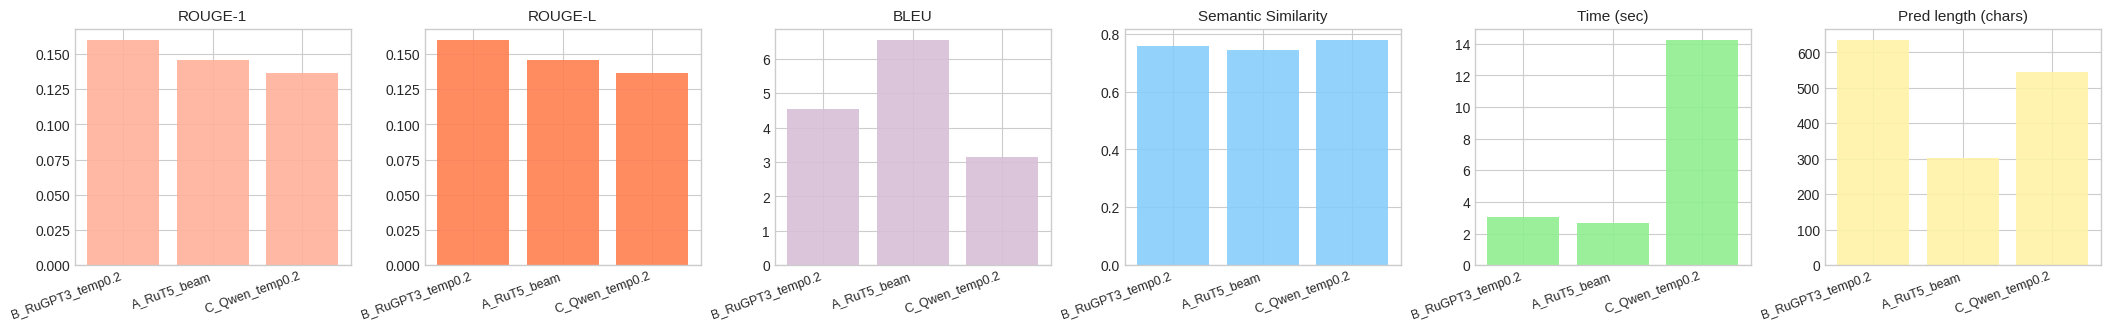

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

baseline = df_summary.copy()
baseline = baseline[baseline["run_name"].isin([
    "A_RuT5_beam",
    "B_RuGPT3_temp0.2",
    "C_Qwen_temp0.2"
])].copy()

baseline = baseline.sort_values("rougeL_mean", ascending=False).reset_index(drop=True)

x = np.arange(len(baseline))
labels = baseline["run_name"].tolist()

# Пастельные цвета
peach = "#FFB199"   # ROUGE-1
coral = "#FF7F50"   # ROUGE-L
lav   = "#D8BFD8"   # BLEU
sky   = "#87CEFA"   # SemSim
mint  = "#90EE90"   # Time
butter= "#FFF2A6"   # Length

fig, axes = plt.subplots(1, 6, figsize=(21, 3.2), constrained_layout=True)

# ROUGE-1
axes[0].bar(x, baseline["rouge1_mean"], color=peach, alpha=0.9)
axes[0].set_title("ROUGE-1", fontsize=11)

# ROUGE-L
axes[1].bar(x, baseline["rougeL_mean"], color=coral, alpha=0.9)
axes[1].set_title("ROUGE-L", fontsize=11)

# BLEU
axes[2].bar(x, baseline["bleu_mean"], color=lav, alpha=0.9)
axes[2].set_title("BLEU", fontsize=11)

# Semantic Similarity
axes[3].bar(x, baseline["sem_sim_mean"], color=sky, alpha=0.9)
axes[3].set_title("Semantic Similarity", fontsize=11)

# Generation Time
axes[4].bar(x, baseline["gen_time_mean"], color=mint, alpha=0.9)
axes[4].set_title("Time (sec)", fontsize=11)

# Pred length
axes[5].bar(x, baseline["pred_len_chars_mean"], color=butter, alpha=0.9)
axes[5].set_title("Pred length (chars)", fontsize=11)

# общие подписи оси X (чтобы не дублировать настройки)
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)

plt.show()


In [29]:
from IPython.display import display

baseline_runs = ["A_RuT5_beam", "B_RuGPT3_temp0.2", "C_Qwen_temp0.2"]

def show_examples(part: pd.DataFrame, title: str, n: int = 3, text_preview: int = 350):
    print("\n" + title)
    display(part[["title", "rougeL", "rouge1", "bleu", "sem_sim", "pred_len_chars"]].head(n))

    for i, row in part.head(n).iterrows():
        print("\n" + "-"*90)
        print("📰 TITLE:", row["title"])
        print(f"📊 ROUGE-L={row['rougeL']:.4f} | ROUGE-1={row['rouge1']:.4f} | BLEU={row['bleu']:.2f} | SemSim={row['sem_sim']:.4f}")
        print("\n📝 TEXT (preview):")
        print(row["text"][:text_preview].replace("\n", " ") + "…")
        print("\n🤖 PRED SUMMARY:")
        print(row["pred"])
        print("\n✅ REFERENCE SUMMARY:")
        print(row["reference_summary"])

for rn in baseline_runs:
    part = df_metrics[df_metrics["run_name"] == rn].copy().sort_values("rougeL", ascending=False)

    print("\n" + "="*100)
    print("RUN:", rn)

    # TOP-3
    show_examples(part, "✅ TOP-3 по ROUGE-L", n=3)

    # WORST-3
    show_examples(part.tail(3).sort_values("rougeL", ascending=True), "❌ WORST-3 по ROUGE-L", n=3)



RUN: A_RuT5_beam

✅ TOP-3 по ROUGE-L


,title,rougeL,rouge1,bleu,sem_sim,pred_len_chars
29,Мясников допустил возникновение пандемии вирус...,1.000000,1.000000,10.516546,0.863809,286
2,Глава Ford обвинил Tesla в запуске недоработан...,0.666667,0.666667,6.196011,0.670845,310
18,Что будет с экономикой США после выборов прези...,0.666667,0.666667,2.779328,0.496490,244



------------------------------------------------------------------------------------------
📰 TITLE: Мясников допустил возникновение пандемии вируса со смертностью 35-40% 
📊 ROUGE-L=1.0000 | ROUGE-1=1.0000 | BLEU=10.52 | SemSim=0.8638

📝 TEXT (preview):
Человечеству может грозить куда более серьезная пандемия, чем распространение коронавируса COVID-19, спрогнозировал в своем Telegram-канале врач и телеведущий Александр Мясников. По его словам, в мире в ближайшее время может начаться эпидемия с большим уровнем смертности, нынешнее же развитие эпидемического процесса таковым не является. «Необходимо…

🤖 PRED SUMMARY:
Человеку грозит куда более серьезная пандемия, чем распространение коронавируса COVID-19, сообщил врач и телеведущий Александр Мясников. По его словам, в ближайшее время может начаться эпидемия с большим уровнем смертности, нынешнее развитие эпидемического процесса таковым не является.

✅ REFERENCE SUMMARY:
Врач Александр Мясников предупредил об опасности возникновения в мир

,title,rougeL,rouge1,bleu,sem_sim,pred_len_chars
23,Ученые: невыход из декрета грозит ускоренной п...,0.0,0.0,3.146217,0.800026,240
27,"Ученые нашли в мозге гены, активность которых ...",0.0,0.0,10.461725,0.854133,158
28,Путин принял участие в поднятии флага на новом...,0.0,0.0,2.644861,0.703152,219



------------------------------------------------------------------------------------------
📰 TITLE: Ученые: невыход из декрета грозит ускоренной потерей памяти 
📊 ROUGE-L=0.0000 | ROUGE-1=0.0000 | BLEU=3.15 | SemSim=0.8000

📝 TEXT (preview):
Если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать в будущем от нарушений памяти возрастают в полтора раза, выяснили ученые из Калифорнийского университета в Лос-Анджелесе. Исследование было опубликовано в журнале Neurology. В Великобритании трудоустроены около 78% женщин, в России — чуть больше 50%. После рожд…

🤖 PRED SUMMARY:
Если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать от нарушений памяти возрастают в полтора раза, выяснили американские ученые. Это повышает их риски от болезни Альцгеймера, предупреждают исследователи.

✅ REFERENCE SUMMARY:
Память неработающих женщин с возрастом ухудшается на 50% быстрее, выяснили ученые из США. Если женщина не работала всю жизнь 

...


------------------------------------------------------------------------------------------
📰 TITLE: Ученые: невыход из декрета грозит ускоренной потерей памяти 
📊 ROUGE-L=0.0000 | ROUGE-1=0.0000 | BLEU=3.08 | SemSim=0.7275

📝 TEXT (preview):
Если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать в будущем от нарушений памяти возрастают в полтора раза, выяснили ученые из Калифорнийского университета в Лос-Анджелесе. Исследование было опубликовано в журнале Neurology. В Великобритании трудоустроены около 78% женщин, в России — чуть больше 50%. После рожд…

🤖 PRED SUMMARY:
если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать в будущем от нарушений памяти возрастают в полтора раза, выяснили ученые. Если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать в будущем от нарушений памяти возрастают в полтора раза.Если женщина после рождения ребенка не выходит из декрета на работу, ее риски по

,title,rougeL,rouge1,bleu,sem_sim,pred_len_chars
86,"Психиатры сообщили, что толкнуло 19-летнего Га...",1.0,1.0,1.779061,0.895874,515
62,Глава Ford обвинил Tesla в запуске недоработан...,0.8,0.8,0.764971,0.643052,632
89,Мясников допустил возникновение пандемии вирус...,0.8,0.8,3.213955,0.884944,654



------------------------------------------------------------------------------------------
📰 TITLE: Психиатры сообщили, что толкнуло 19-летнего Галявиева на расстрел в казанской школе 
📊 ROUGE-L=1.0000 | ROUGE-1=1.0000 | BLEU=1.78 | SemSim=0.8959

📝 TEXT (preview):
19-летний Ильназ Галявиев, который устроил стрельбу в казанской школе, в феврале-марте 2021 года мог впасть в острый психоз, в результате которого у него возникли мысли о преступлении. Об этом «Газете.Ru» рассказал врач-психиатр, эксперт-профайлер Алексей Филатов. «Тут портрета и составлять не нужно. Очевидно, что там болезнь — человек находится в …

🤖 PRED SUMMARY:
19-летний Ильназ Галявиев, устроивший стрельбу в школе в Казани, мог впасть в острый психоз, что вызвало у него мысли о преступлении. Эксперт-профайлер Алексей Филатов отметил, что хотя психоз Галявиева не делает его полностью безумным, он способен мыслить рационально. Психиатр Роман Партницын, однако, полагает, что Галявиев страдает шизофренией. Независимая нар

,title,rougeL,rouge1,bleu,sem_sim,pred_len_chars
83,Ученые: невыход из декрета грозит ускоренной п...,0.0,0.0,0.717921,0.798512,643
87,"Ученые нашли в мозге гены, активность которых ...",0.0,0.0,7.272529,0.843652,518
88,Путин принял участие в поднятии флага на новом...,0.0,0.0,2.050518,0.782122,588



------------------------------------------------------------------------------------------
📰 TITLE: Ученые: невыход из декрета грозит ускоренной потерей памяти 
📊 ROUGE-L=0.0000 | ROUGE-1=0.0000 | BLEU=0.72 | SemSim=0.7985

📝 TEXT (preview):
Если женщина после рождения ребенка не выходит из декрета на работу, ее риски пострадать в будущем от нарушений памяти возрастают в полтора раза, выяснили ученые из Калифорнийского университета в Лос-Анджелесе. Исследование было опубликовано в журнале Neurology. В Великобритании трудоустроены около 78% женщин, в России — чуть больше 50%. После рожд…

🤖 PRED SUMMARY:
Ученые из Калифорнийского университета в Лос-Анджелесе провели исследование, которое показывает, что женщины, которые продолжают работать после рождения ребенка, имеют более медленное ухудшение памяти по мере старения. Исследование, опубликованное в журнале Neurology, основано на данных 6189 женщин старше 55 лет. Оно показало, что те, кто работал после рождения ребенка, имели более мед

## LLM-AS-A-JUDGE

In [41]:
import pandas as pd
import numpy as np
import time

JUDGE_MAX = 90  # 90 чтобы оценить всё (30*3)

df_to_judge = df_metrics.copy()
if len(df_to_judge) > JUDGE_MAX:
    df_to_judge = df_to_judge.sample(JUDGE_MAX, random_state=SEED)

judge_rows = []
times = []
t0_run = time.time()

print("="*100)
print(f"⚖️ START GPT-JUDGE | rows={len(df_to_judge)} | model={JUDGE_MODEL}")

for j, (_, r) in enumerate(df_to_judge.iterrows(), start=1):
    out = judge_one(
        article=r["text"],
        reference=r["reference_summary"],
        candidate=r["pred"],
    )

    judge_rows.append({
        "run_name": r["run_name"],
        "idx": int(r["idx"]),
        "judge_score": out.get("score", None),
        "judge_comment": out.get("comment", ""),
        "judge_time_sec": out.get("_judge_time_sec", None),
    })

    dt = out.get("_judge_time_sec", None)
    if dt is not None:
        times.append(dt)

    # ✅ прогресс каждые 5 примеров + первый + последний
    if (j == 1) or (j % 5 == 0) or (j == len(df_to_judge)):
        avg_t = float(np.mean(times)) if len(times) > 0 else float("nan")
        elapsed = time.time() - t0_run
        remaining = len(df_to_judge) - j
        eta = avg_t * remaining if len(times) > 0 else float("nan")

        score = out.get("score", None)
        comment = (out.get("comment", "") or "").replace("\n", " ")
        comment_preview = comment[:120] + ("…" if len(comment) > 120 else "")

        print(f"\n[{j}/{len(df_to_judge)}] ✅ run={r['run_name']} idx={int(r['idx'])}")
        print(f"⏱ judge_time={dt:.2f}s | avg={avg_t:.2f}s | elapsed={elapsed:.1f}s | ETA≈{eta:.1f}s")
        print(f"⭐ score={score} | comment: {comment_preview}")

print(f"\n✅ FINISH GPT-JUDGE | total_time={time.time() - t0_run:.1f}s")
print("="*100)

df_judge = pd.DataFrame(judge_rows)
df_judge.head()


⚖️ START GPT-JUDGE | rows=90 | model=gpt-4.1

[1/90] ✅ run=A_RuT5_beam idx=0
⏱ judge_time=2.45s | avg=2.45s | elapsed=2.4s | ETA≈217.8s
⭐ score=3 | comment: Саммари сохраняет один из ключевых фактов — заявление Трампа о готовности вернуть войска в Афганистан, однако вторая час…

[5/90] ✅ run=A_RuT5_beam idx=4
⏱ judge_time=2.06s | avg=2.86s | elapsed=14.3s | ETA≈243.3s
⭐ score=7 | comment: Кандидат хорошо отразил ключевой факт о реакции МИД Азербайджана на слова Жириновского, а также указал предложение о вли…

[10/90] ✅ run=A_RuT5_beam idx=9
⏱ judge_time=1.73s | avg=2.58s | elapsed=25.8s | ETA≈206.2s
⭐ score=8 | comment: Саммари сохраняет ключевые факты статьи — обсуждение возможного размещения войск в Узбекистане и Таджикистане, а также а…

[15/90] ✅ run=A_RuT5_beam idx=14
⏱ judge_time=2.01s | avg=2.39s | elapsed=35.9s | ETA≈179.3s
⭐ score=8 | comment: Саммари включает ключевой факт об обнаружении воды на освещенной части Луны и отмечает значимость для будущих миссий. Од…

[20/90] ✅ ru

,run_name,idx,judge_score,judge_comment,judge_time_sec
0,A_RuT5_beam,0,3,Саммари сохраняет один из ключевых фактов — за...,2.446891
1,A_RuT5_beam,1,9,"Саммари точно отражает ключевые факты статьи, ...",2.565217
2,A_RuT5_beam,2,6,В саммари отражены основные обвинения Ford в а...,2.451687
3,A_RuT5_beam,3,7,Саммари сохраняет ключевые факты о технологиче...,4.789196
4,A_RuT5_beam,4,7,Кандидат хорошо отразил ключевой факт о реакци...,2.059737


In [42]:
df_judge_summary = (
    df_judge
    .groupby("run_name", as_index=False)
    .agg(
        judge_score_mean=("judge_score", "mean"),
        judge_score_std=("judge_score", "std"),
        judge_time_mean=("judge_time_sec", "mean"),
        n=("judge_score", "count")
    )
    .sort_values("judge_score_mean", ascending=False)
)

df_judge_summary

,run_name,judge_score_mean,judge_score_std,judge_time_mean,n
2,C_Qwen_temp0.2,7.633333,0.927857,2.636578,30
0,A_RuT5_beam,6.066667,1.529781,2.479687,30
1,B_RuGPT3_temp0.2,4.733333,1.529781,2.594874,30


In [43]:
df_metrics_with_judge = df_metrics.merge(
    df_judge,
    on=["run_name", "idx"],
    how="left"
)

df_metrics_with_judge.head()

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars,rouge1,rougeL,bleu,sem_sim,judge_score,judge_comment,judge_time_sec
0,A_RuT5_beam,0,Экс-президент США призвал армию быть готовой к...,Американские вооруженные силы должны быть гото...,Экс-президент США продолжает критиковать админ...,"Бывший глава Белого дома Дональд Трамп заявил,...",3.884613,328,0.000000,0.000000,21.875977,0.777087,3,Саммари сохраняет один из ключевых фактов — за...,2.446891
1,A_RuT5_beam,1,Профессор астрономии из США объявил о новой ин...,"Международный коллектив ученых из Гарварда , П...",Международный коллектив под руководством гарва...,"Международный коллектив ученых из Гарварда, Пр...",2.572632,391,0.000000,0.000000,2.764425,0.792796,9,"Саммари точно отражает ключевые факты статьи, ...",2.565217
2,A_RuT5_beam,2,Глава Ford обвинил Tesla в запуске недоработан...,Генеральный директор Ford Джим Фарли обвиняет ...,Руководство Ford в очередной раз сделало выпад...,Генеральный директор Ford Джим Фарли обвинил T...,2.298973,310,0.666667,0.666667,6.196011,0.670845,6,В саммари отражены основные обвинения Ford в а...,2.451687
3,A_RuT5_beam,3,Спецпредставитель президента ожидает новой «бы...,Спецпредставитель президента РФ по связям с ме...,Анатолий Чубайс заявил о формировании в ближай...,В обозримом будущем новая технологическая рево...,3.295526,432,0.000000,0.000000,2.175701,0.854368,7,Саммари сохраняет ключевые факты о технологиче...,4.789196
4,A_RuT5_beam,4,Жириновский упрекнул Азербайджан после протест...,МИД Азербайджана вызвал временного поверенного...,"Лидер ЛДПР, депутат Владимир Жириновский вызва...",МИД Азербайджана вызвал временного поверенного...,3.636726,316,0.000000,0.000000,1.305983,0.691229,7,Кандидат хорошо отразил ключевой факт о реакци...,2.059737


In [44]:
baseline_runs = ["A_RuT5_beam", "B_RuGPT3_temp0.2", "C_Qwen_temp0.2"]

for rn in baseline_runs:
    part = df_metrics_with_judge[df_metrics_with_judge["run_name"] == rn].copy()
    part = part.dropna(subset=["judge_score"]).sort_values("judge_score", ascending=False)

    print("\n" + "="*90)
    print("RUN:", rn)

    print("\n✅ TOP-3 по Judge Score")
    display(part[["title", "judge_score", "judge_comment", "rougeL", "sem_sim", "pred_len_chars"]].head(3))

    print("\n❌ WORST-3 по Judge Score")
    display(part[["title", "judge_score", "judge_comment", "rougeL", "sem_sim", "pred_len_chars"]].tail(3))



RUN: A_RuT5_beam

✅ TOP-3 по Judge Score


,title,judge_score,judge_comment,rougeL,sem_sim,pred_len_chars
1,Профессор астрономии из США объявил о новой ин...,9,"Саммари точно отражает ключевые факты статьи, ...",0.0,0.792796,391
9,WSJ: США могут разместить выведенные из Афгани...,8,Саммари сохраняет ключевые факты статьи — обсу...,0.0,0.822987,382
20,Около трети россиян готовы сменить работу в 20...,8,Саммари хорошо отражает ключевые факты об ожид...,0.0,0.885480,411



❌ WORST-3 по Judge Score


,title,judge_score,judge_comment,rougeL,sem_sim,pred_len_chars
19,В Роспотребнадзоре рассказали о количестве мут...,4,В саммари искажена структура фактов: создается...,0.200000,0.632731,225
0,Экс-президент США призвал армию быть готовой к...,3,Саммари сохраняет один из ключевых фактов — за...,0.000000,0.777087,328
18,Что будет с экономикой США после выборов прези...,3,Саммари сохранило только дату выборов и часть ...,0.666667,0.496490,244



RUN: B_RuGPT3_temp0.2

✅ TOP-3 по Judge Score


...

,title,judge_score,judge_comment,rougeL,sem_sim,pred_len_chars
49,В Роспотребнадзоре рассказали о количестве мут...,3,"Саммари слишком длинное, содержит много цитат ...",0.095238,0.707243,848
53,Ученые: невыход из декрета грозит ускоренной п...,3,Саммари повторяет одну и ту же фразу и не охва...,0.000000,0.727476,653
48,Что будет с экономикой США после выборов прези...,2,Саммари содержит фактические ошибки («победа Т...,0.400000,0.615832,324



RUN: C_Qwen_temp0.2

✅ TOP-3 по Judge Score


,title,judge_score,judge_comment,rougeL,sem_sim,pred_len_chars
60,Экс-президент США призвал армию быть готовой к...,9,Саммари хорошо отражает ключевые факты статьи:...,0.0,0.864765,615
61,Профессор астрономии из США объявил о новой ин...,9,Саммари четко и кратко отражает ключевые факты...,0.0,0.777497,449
67,"Сергей Шойгу — о братском народе Украины, ново...",9,Саммари охватывает большинство ключевых фактов...,0.0,0.808486,512



❌ WORST-3 по Judge Score


,title,judge_score,judge_comment,rougeL,sem_sim,pred_len_chars
65,Песков оценил встречу Зеленского и Байдена,6,Саммари сохраняет большинство ключевых фактов ...,0.0,0.685832,430
78,Что будет с экономикой США после выборов прези...,6,Саммари кратко и грамотно передает основные пр...,0.4,0.558563,618
82,В Минске на акции протеста студентов задержива...,5,В кандидате сохранены основные факты о студенч...,0.0,0.770775,433


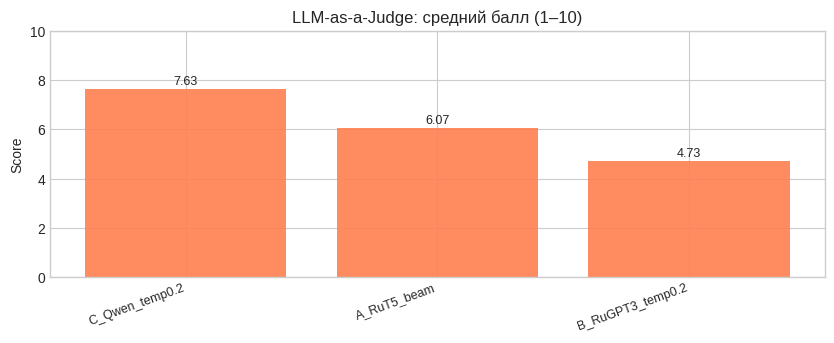

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

tbl = df_judge_summary.copy().reset_index(drop=True)
x = np.arange(len(tbl))

coral = "#FF7F50"

plt.figure(figsize=(10, 3.2))
bars = plt.bar(x, tbl["judge_score_mean"], color=coral, alpha=0.9)

plt.xticks(x, tbl["run_name"], rotation=20, ha="right", fontsize=9)
plt.title("LLM-as-a-Judge: средний балл (1–10)", fontsize=12)
plt.ylabel("Score")

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.05, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 10)  # шкала судьи 1..10
plt.show()


### Вывод

Реализована собственная метрика качества суммаризации LLM-as-a-Judge: итоговое саммари оценивается более сильной моделью GPT-4 (gpt-4.1).
Судья сравнивает саммари с исходной статьёй и эталоном и выставляет итоговую оценку от 1 до 10 + короткий комментарий, учитывая сохранение ключевых фактов, отсутствие выдуманных деталей, краткость и связность текста.

**ГПТ отдает предпочтение Qwen, хотя другие метрики по нему ниже.**

ROUGE/BLEU меряют совпадение слов, а судья — качество смысла.
ROUGE и BLEU сильно завязаны на лексическое совпадение n-грамм с эталоном.
Если Qwen перефразирует — может передать смысл хорошо, но словами синонимами, поэтому ROUGE/BLEU падают.

Вывод - использовать комбинированные метрики для оценки качества.

### Сравнение с бенчмарками

В карточках моделей автора на Hugging Face приведены результаты на Gazeta v1 test (ROUGE-1/2/L, BLEU и др.).
Сравним наши результаты (на 30 примерах) с этими бенчмарками:

📌 Сравнение ROUGE-1 (чем больше — тем лучше)
- RuT5-base SumGazeta	Бенчмарк 32.2 vs	наш - 0.1456 (≈ 14.6)
- RuGPT3-medium SumGazeta	Бенчмарк 26.2 vs	наш -0.1600 (≈ 16.0)

Почему ROUGE заметно ниже бенчмарков:

- Маленькая выборка: мы оценивали только 30 случайных текстов, а бенчмарк считается на полном тесте → разброс выше.

- Другие предобработка/оценка, параметры генерации.


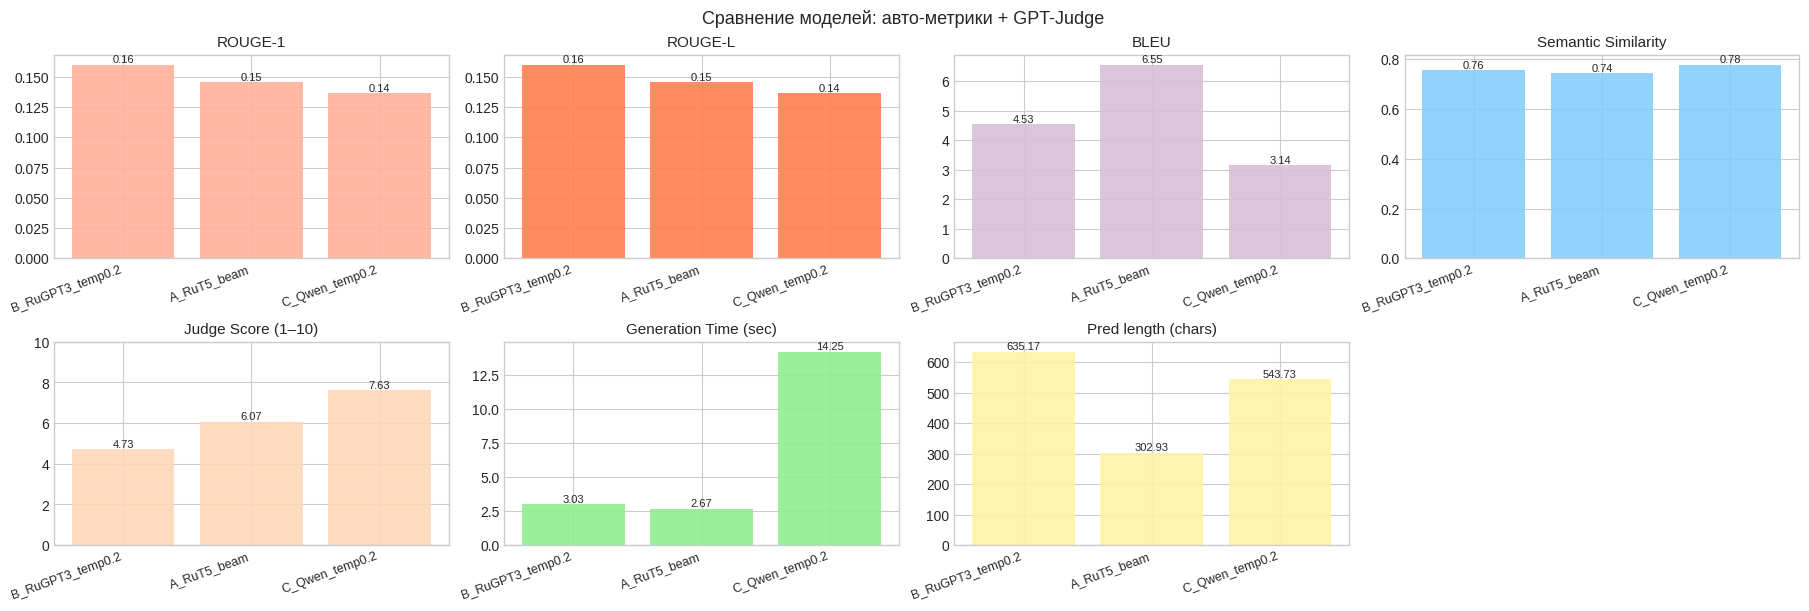

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# ✅ объединяем авто-метрики + судью
df_all = df_summary.merge(
    df_judge_summary[["run_name", "judge_score_mean"]],
    on="run_name",
    how="left"
)

baseline_names = ["A_RuT5_beam", "B_RuGPT3_temp0.2", "C_Qwen_temp0.2"]
df_all = df_all[df_all["run_name"].isin(baseline_names)].copy()

df_all = df_all.sort_values("rougeL_mean", ascending=False).reset_index(drop=True)

labels = df_all["run_name"].tolist()
x = np.arange(len(df_all))

colors = {
    "rouge1_mean": "#FFB199",         # peach
    "rougeL_mean": "#FF7F50",         # coral
    "bleu_mean": "#D8BFD8",           # lavender
    "sem_sim_mean": "#87CEFA",        # sky
    "judge_score_mean": "#FFD7BA",    # soft coral-beige
    "gen_time_mean": "#90EE90",       # mint
    "pred_len_chars_mean": "#FFF2A6", # butter
}

metrics = [
    ("rouge1_mean", "ROUGE-1"),
    ("rougeL_mean", "ROUGE-L"),
    ("bleu_mean", "BLEU"),
    ("sem_sim_mean", "Semantic Similarity"),
    ("judge_score_mean", "Judge Score (1–10)"),
    ("gen_time_mean", "Generation Time (sec)"),
    ("pred_len_chars_mean", "Pred length (chars)"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 6), constrained_layout=True)
axes = axes.flatten()

for i, (col, title) in enumerate(metrics):
    ax = axes[i]
    vals = df_all[col].values

    bars = ax.bar(x, vals, color=colors[col], alpha=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)

    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

    # фиксируем шкалу для judge
    if col == "judge_score_mean":
        ax.set_ylim(0, 10)

axes[-1].axis("off")

plt.suptitle("Сравнение моделей: авто-метрики + GPT-Judge", fontsize=13)
plt.show()


## Влияние температуры

In [49]:
N_TEMP_SAMPLES = 10

eval_ds_temp = ds["test"].shuffle(seed=SEED + 123).select(range(N_TEMP_SAMPLES))

df_temp = pd.DataFrame({
    "title": [x["title"] for x in eval_ds_temp],
    "text": [x["text"] for x in eval_ds_temp],
    "reference_summary": [x["summary"] for x in eval_ds_temp],
})

print("✅ df_temp shape:", df_temp.shape)
df_temp.head(3)


✅ df_temp shape: (10, 3)


,title,text,reference_summary
0,В России биржевая цена дизельного топлива поби...,Стоимость летнего дизельного топлива на Санкт-...,Дизельное топливо на биржевых торгах достигло ...
1,Агутина выдвинули на «Грэмми» в пяти номинациях,Альбом «La Vida Cosmopolita» заслуженного арти...,Альбом Леонида Агутина выдвинули на «Грэмми» в...
2,Как существенно упростить получения разрешений...,На основании рейтинга Всемирного Банка простот...,Еще одна идея предпринимателя-энтузиаста Дмитр...


In [51]:
all_runs_temp = []

print("\n📦 Loading Model B: RuGPT3...")
tok_b, mod_b = load_rugpt3()

# --- Run 1: temperature=0.1 ---
df_b1 = run_on_dataset(
    df_temp,
    gen_fn=lambda text, **kw: gen_rugpt3(tok_b, mod_b, text, **kw),
    gen_kwargs={"max_input_len": 1024, "max_new_tokens": 200, "temperature": 0.1},
    run_name="B_RuGPT3_1_temp0.1",
    log_every=2
)
all_runs_temp.append(df_b1)

# --- Run 2: temperature=0.9 ---
df_b2 = run_on_dataset(
    df_temp,
    gen_fn=lambda text, **kw: gen_rugpt3(tok_b, mod_b, text, **kw),
    gen_kwargs={"max_input_len": 1024, "max_new_tokens": 200, "temperature": 0.9},
    run_name="B_RuGPT3_2_temp0.9",
    log_every=2
)
all_runs_temp.append(df_b2)

# --- Run 3: temperature=10 (экстремально высокая) ---
df_b3 = run_on_dataset(
    df_temp,
    gen_fn=lambda text, **kw: gen_rugpt3(tok_b, mod_b, text, **kw),
    gen_kwargs={"max_input_len": 1024, "max_new_tokens": 200, "temperature": 10.0},
    run_name="B_RuGPT3_3_temp10",
    log_every=2
)
all_runs_temp.append(df_b3)

free_gpu(mod_b, tok_b)

df_preds_temp = pd.concat(all_runs_temp, ignore_index=True)
df_preds_temp.head(2)



📦 Loading Model B: RuGPT3...
🚀 START RUN: B_RuGPT3_1_temp0.1
🔧 gen_kwargs: {'max_input_len': 1024, 'max_new_tokens': 200, 'temperature': 0.1}

[B_RuGPT3_1_temp0.1] 1/10 ✅ idx=0
📰 title: В России биржевая цена дизельного топлива побила исторический рекорд 
⏱ gen_time=4.56s | step_wall=4.57s | avg=4.56s | elapsed=4.6s | ETA≈41.0s | GPU alloc=5.09GB reserved=5.91GB
📝 summary_preview: цена дизтоплива в России достигла максимума с 2018 года. С начала июня этот показатель вырос на 2,21%. В агентстве Argus рост цен связывают с недостаточным предложением топлива из-…

[B_RuGPT3_1_temp0.1] 2/10 ✅ idx=1
📰 title: Агутина выдвинули на «Грэмми» в пяти номинациях 
⏱ gen_time=4.40s | step_wall=4.41s | avg=4.48s | elapsed=9.0s | ETA≈35.8s | GPU alloc=5.09GB reserved=5.91GB
📝 summary_preview: Леонид Агутин попал в лонг-лист музыкальной премии «Грэмми» в пяти номинациях. Об этом сообщила пресс-секретарь певца Наталия Николенко. Согласно ее словам, голосование, по результ…

[B_RuGPT3_1_temp0.1] 4/10 ✅ i

,run_name,idx,title,text,reference_summary,pred,gen_time_sec,pred_len_chars
0,B_RuGPT3_1_temp0.1,0,В России биржевая цена дизельного топлива поби...,Стоимость летнего дизельного топлива на Санкт-...,Дизельное топливо на биржевых торгах достигло ...,цена дизтоплива в России достигла максимума с ...,4.558369,875
1,B_RuGPT3_1_temp0.1,1,Агутина выдвинули на «Грэмми» в пяти номинациях,Альбом «La Vida Cosmopolita» заслуженного арти...,Альбом Леонида Агутина выдвинули на «Грэмми» в...,Леонид Агутин попал в лонг-лист музыкальной пр...,4.403052,741


In [52]:
summary_rows = []
df_with_metrics_list = []

for run_name, part in df_preds_temp.groupby("run_name"):
    part = part.copy()
    part, agg = compute_all_metrics(part)
    agg["run_name"] = run_name
    summary_rows.append(agg)
    df_with_metrics_list.append(part)

df_metrics_temp = pd.concat(df_with_metrics_list, ignore_index=True)
df_summary_temp = pd.DataFrame(summary_rows).sort_values("rougeL_mean", ascending=False)

df_summary_temp


,rouge1_mean,rougeL_mean,bleu_mean,sem_sim_mean,gen_time_mean,pred_len_chars_mean,run_name
0,0.115000,0.115000,2.850339,0.695696,3.196794,655.3,B_RuGPT3_1_temp0.1
1,0.105385,0.105385,3.312165,0.738963,3.593757,746.9,B_RuGPT3_2_temp0.9
2,0.008000,0.008000,0.544142,0.506018,4.423606,934.2,B_RuGPT3_3_temp10


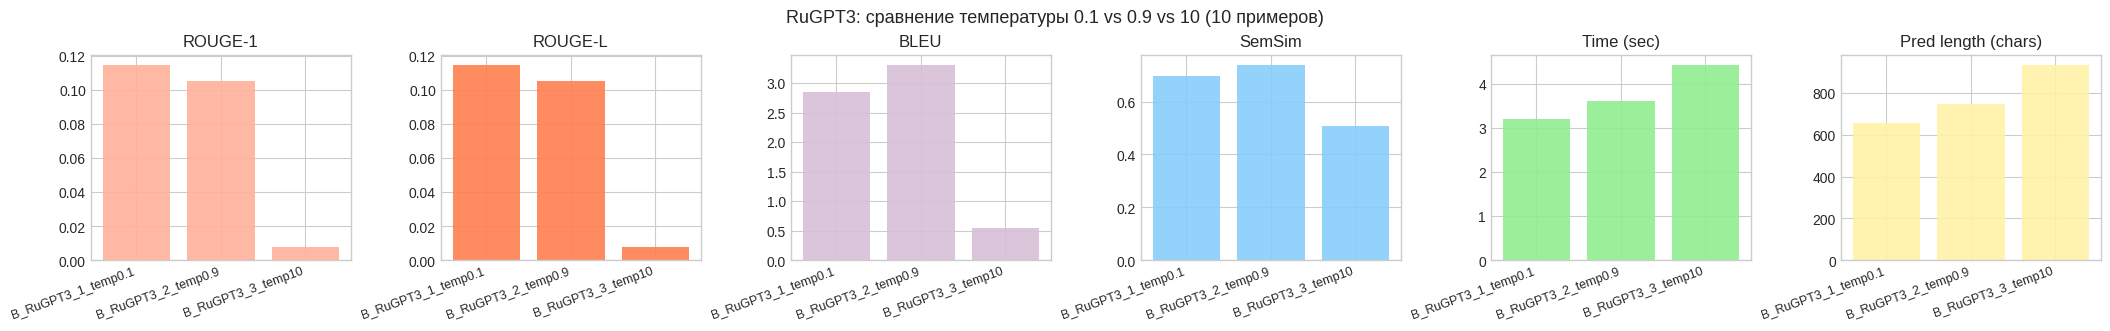

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import re

plt.style.use("seaborn-v0_8-whitegrid")

tbl = df_summary_temp.copy()

# ✅ сортируем по температуре, чтобы было 0.1 -> 0.9 -> 10
def extract_temp(name: str):
    m = re.search(r"temp([0-9.]+)", name)
    return float(m.group(1)) if m else 999

tbl["temp"] = tbl["run_name"].apply(extract_temp)
tbl = tbl.sort_values("temp").reset_index(drop=True)

x = np.arange(len(tbl))
labels = tbl["run_name"].tolist()

# пастельные цвета
peach = "#FFB199"   # ROUGE-1
coral = "#FF7F50"   # ROUGE-L
lav   = "#D8BFD8"   # BLEU
sky   = "#87CEFA"   # SemSim
mint  = "#90EE90"   # time
butter= "#FFF2A6"   # length

fig, axes = plt.subplots(1, 6, figsize=(21, 3.2), constrained_layout=True)

axes[0].bar(x, tbl["rouge1_mean"], color=peach, alpha=0.9);  axes[0].set_title("ROUGE-1")
axes[1].bar(x, tbl["rougeL_mean"], color=coral, alpha=0.9);  axes[1].set_title("ROUGE-L")
axes[2].bar(x, tbl["bleu_mean"],   color=lav,   alpha=0.9);  axes[2].set_title("BLEU")
axes[3].bar(x, tbl["sem_sim_mean"],color=sky,   alpha=0.9);  axes[3].set_title("SemSim")
axes[4].bar(x, tbl["gen_time_mean"],color=mint, alpha=0.9);  axes[4].set_title("Time (sec)")
axes[5].bar(x, tbl["pred_len_chars_mean"], color=butter, alpha=0.9); axes[5].set_title("Pred length (chars)")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)

plt.suptitle("RuGPT3: сравнение температуры 0.1 vs 0.9 vs 10 (10 примеров)", fontsize=13)
plt.show()


In [40]:
# Соберём wide-табличку: на каждый idx два предсказания
wide = (
    df_metrics_temp[["idx", "title", "reference_summary", "pred", "run_name", "rougeL", "sem_sim"]]
    .pivot(index="idx", columns="run_name")
)

wide.columns = ["_".join(col).strip() for col in wide.columns.values]
wide = wide.reset_index()

wide.head(2)


,idx,title_B_RuGPT3_1_temp0.1,title_B_RuGPT3_2_temp0.9,reference_summary_B_RuGPT3_1_temp0.1,reference_summary_B_RuGPT3_2_temp0.9,pred_B_RuGPT3_1_temp0.1,pred_B_RuGPT3_2_temp0.9,rougeL_B_RuGPT3_1_temp0.1,rougeL_B_RuGPT3_2_temp0.9,sem_sim_B_RuGPT3_1_temp0.1,sem_sim_B_RuGPT3_2_temp0.9
0,0,В России биржевая цена дизельного топлива поби...,В России биржевая цена дизельного топлива поби...,Дизельное топливо на биржевых торгах достигло ...,Дизельное топливо на биржевых торгах достигло ...,цена дизтоплива в России достигла максимума с ...,"1,5 тыс. руб. за тонну — это очень дорого, осо...",0.25,0.4,0.786927,0.787198
1,1,Агутина выдвинули на «Грэмми» в пяти номинациях,Агутина выдвинули на «Грэмми» в пяти номинациях,Альбом Леонида Агутина выдвинули на «Грэмми» в...,Альбом Леонида Агутина выдвинули на «Грэмми» в...,Леонид Агутин попал в лонг-лист музыкальной пр...,Альбом «La Vida Cosmopolita» заслуженного арти...,0.00,0.0,0.723834,0.692936


### Вывод

**Сравнение температуры (RuGPT3, 10 примеров):**

При **низкой температуре 0.1** модель генерирует **более стабильные и строгие саммари** (если оценивать визуально), чаще ближе к эталону по формулировкам — это даёт **выше ROUGE и BLEU. Семантическая близость получилась почти одинакова**.
При **высокой температуре 0.9** ответы становятся **более вариативными и свободными и в более разговорном стиле**, чаще появляются **отклонения от исходных фактов и лишняя информация**, из-за чего качество по метрикам может снижаться.
На 0.9 качество суммаризации тоже вполне неплохое, если смотреть в целом по метрикам.

На экстремально высокой температуре = 10 генерация становится очень непредсказуемой, метрики резко падают в качестве.


**Вывод:** для задачи суммаризации новостей оптимальнее использовать **низкую температуру (≈0.1–0.3)**, а высокая подходит скорее для генерации с большим разнообразием, но не для точного сокращения.
